# Preliminary

## Topics

### Wave propagation formula

$E(x,t) = A \cos(\omega t - k x + \phi)$

- $E$ is the electric field.
- $x$ is the distance from the transmitter along the direction of propagation.
- $k$ is the wave number, equivalent to $k = \frac{2 \pi}{\lambda}$. Represents how fast the field changes with distance.

### Wavelength formula

$c = f \lambda$

- $c$ is the speed of light (m/s).
- $f$ is the frequency (Hz).
- $\lambda$ is the wavelength (m).

In [2]:
c = 299792458 # meters per second
f = -1
l = -1

def compute(frequency, wavelength):
    if frequency == -1 and wavelength == -1:
        return "Set frequency xor wavelength."
    elif frequency == -1:
        return f"At {wavelength} meters, the frequency is {c / wavelength:.2f} Hz."
    return f"At {frequency} Hz, the wavelength is {c / frequency:.2f} meters."

compute(f, l)

'Set frequency xor wavelength.'

### Time to frequency domain

Recall the mathematical representation of a signal of some bandwidth is, and how it appears in the time and frequency domains.

### Near-field and far-field for electrically large antennas

$R = 0.62 \cdot (\frac{D^3}{\lambda})^\frac{1}{2}$

- $R$ is the radius (distance) from the transmitter (m).
- $D$ is the largest physical dimension of the antenna (m).

$R_o = 2 \cdot \frac{D^2}{\lambda}$

#### Near-field
$x < R$

- $x$ is the distance from the transmitter (m).

#### Fresnel region
$R < x < R_o$

#### Far-field
$R_o < x$

## Resolving vs demodulating

Resolution:

$ \text{distance resolution} ≈ \frac{c}{\text{bandwidth}} $


## Key constraints

- What frequencies and bandwidths are allowed
  - [US frequency allocation chart](https://www.ntia.gov/files/ntia/publications/2003-allochrt.pdf)
- What frequencies can penetrate snow effectively
- Antennae size
- Near field / far field distances

## Avalanche-Specific Data and Modelling

- [Median victim burial depth is 1.25 m](https://pubmed.ncbi.nlm.nih.gov/18800960/)
- [Mathematical modelling (need to investigate)](https://chatgpt.com/s/t_69a5bb6cf8648191b51d3bceb1f2c8db)


# Methods of range finding

## TDoA (GPS)

### Resources:
- [How GPS works](https://ciechanow.ski/gps/)
- [Maximum length sequences](https://en.wikipedia.org/wiki/Maximum_length_sequence)
- [Impulse Response Measurements using MLS Technique on Nonsynchronous Devices](https://hal.science/hal-02504349/document)
- [Signal to noise ratio analysis of maximum length sequence deconvolution of overlapping evoked potentials](https://pubs.aip.org/asa/jasa/article-abstract/119/5/2881/893333/Signal-to-noise-ratio-analysis-of-maximum-length?redirectedFrom=fulltext)
- [Two-way ranging with carrier frequency and phase offset compensation based on software defined radio](https://www.sciencedirect.com/science/article/abs/pii/S026322412400544X)
- [Stanford GPS lectures](https://www.youtube.com/@LaintalAy/videos)
- [GPS Pseudolites: Theory, Design, and Applications](https://web.stanford.edu/group/scpnt/gpslab/pubs/theses/StewartCobbThesis97.pdf)
- [Some Considerations in Designing a GPS Pseudolite](https://www.researchgate.net/publication/258607275_Some_Considerations_in_Designing_a_GPS_Pseudolite)

### Premise
- Uses trilateration (time of flight)
- Use the following carrier frequencies: L1, at 1575.42 MHz, and L2, at 1227.6 MHz (newer satellites also broadcast on L5 at 1176 MHz) with a bandwidth around 2 MHz
- Clocks run slower in satellites closer to Earth, faster in satellites farther from Earth
- Satellites use atomic clocks to maintain precise timing
- As part of their broadcasted message, a satellite emits three coefficients that allow the receiver to correct for any offset or speed change of that satellite’s clock
- The clocks on all satellites can’t be perfectly synchronized, so both the positions and timestamps received from satellites are not exact
- The message satellites send to ground-based receivers consists of 25 frames, each of which has 5 subframes. Each subframe, represented by a single row, consists of 10 words, and each word consists of 30 bits
- We have the following sequences of information: data, which is the actual binary data. Code, which is a randomly generated sequence of numbers specific to the satellite sending it, and the carrier, which is a sinusoidal wave. The satellite multiplies $Data \times Code \times Carrier$, and outputs the resulting signal
- These pseudorandom codes define how well a code correlates with its time-shifted copy. By multiplying the actual code with its replica and summing the areas beneath its curves, the closer the code is to its replica, the larger the sum of these areas is. This correlation, called 'auto-correlation', is only high when things are aligned correctly
- These PRNs are also used in 'cross-correlation', which is used to distinguish one satellite's signal from another.
- The receiver tracks a satellite and tries to find a high correlation peak between the input signal and the replica. This lets it know the offset value

### Proposal
- I find a carrier frequency I can legally use within ~200-400 MHz, with as wide a bandwidth as possible. This means I need an antenna of around 1 meter, which I would fold into a physically smaller antenna size.
- I set up two devices, **A** and **B**. **A** encodes a PRN sequence in the carrier frequency, and transmits the signal (using hardware timing) to **B**.
- At the same time, **B** creates a replica PRN sequence, at a specified timestamp defined by its own hardware timer.
- **B** then creates a series of time-shifted samples of its replica sequence, all with known offsets with respect to **B**'s original timestamped PRN sequence.
- When **B** receives the signal from **A**, it uses its shifted samples to perform correlation with **A**'s signal until it finds the sample that matches exactly. By doing so, **B** gets a precise idea of the exact time that **A**'s signal arrived, relative to **B**'s clock.
- **B** then waits for a hardware timer-defined delay of a few microseconds.
- **B** then sends a reply to **A**, which **A** resolves using the same method.
- **A** now knows that the time of flight was $\frac{\text{total time}-\text{known delay of B}}{2}$
- Because the carrier frequency is around 300 MHz, each wavelength is around 1 meter, so phase can be used for fine-grain measuring, while PRN is used for coarse measuring, which helps to remove the ambiguity of the phase measurement.


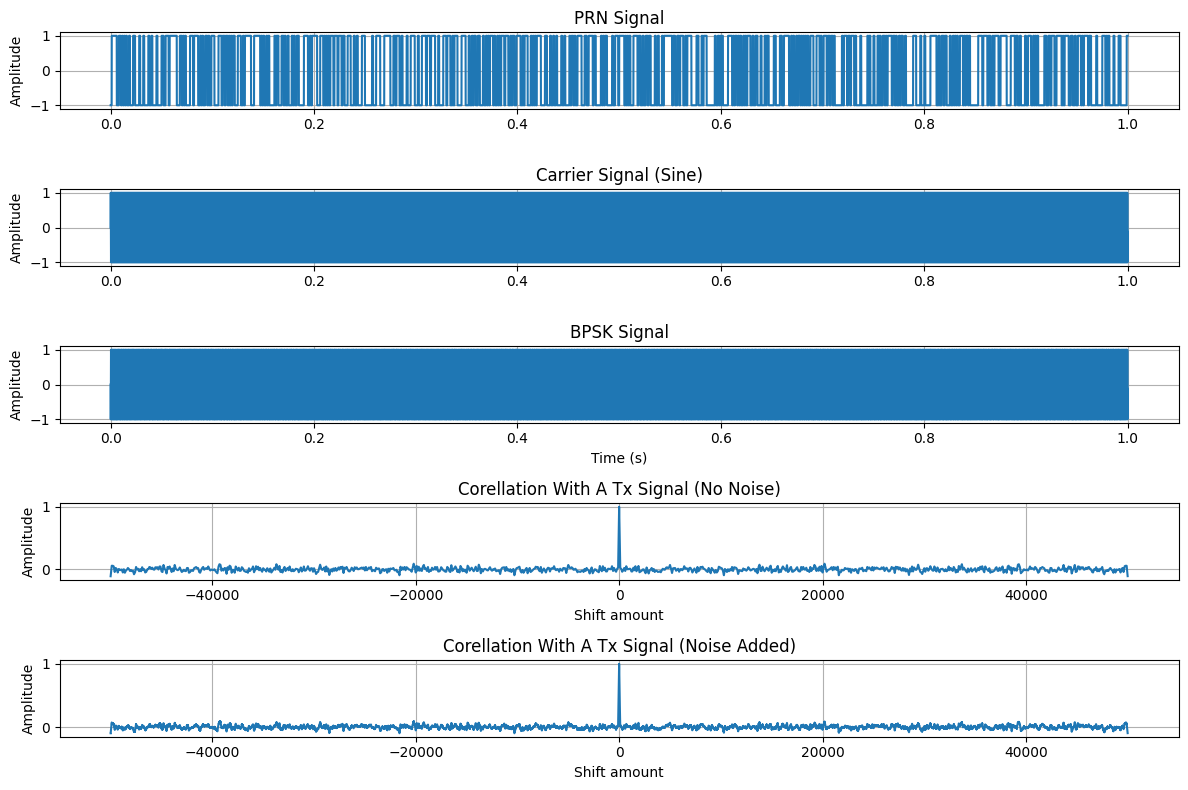

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

##############
# PARAMETERS #
##############

fc = 2000 # Carrier frequency (Hz)
fs = 100000 # Sampling frequency (Hz)
bit_rate = 1000 # Bits per second
num_bits = 1000 # Number of PRN bits
noise_std = 2.0

########################
# PRN AND BPSK SIGNALS #
########################

Tb = 1 / bit_rate
t = np.arange(0, num_bits * Tb, 1/fs)

# Generate the PRN sequence
bits = np.random.randint(0, 2, num_bits)
prn = 2 * bits - 1  # Convert {0,1} → {-1,+1}

samples_per_bit = int(fs * Tb)
prn_upsampled = np.repeat(prn, samples_per_bit)

carrier = np.sin(2 * np.pi * fc * t)

bpsk_signal = prn_upsampled * carrier

###################
# NOISY TX SIGNAL #
###################

# Add noise to the transmitter's PRN signal to simulate real-world conditions
noise = np.random.normal(0, noise_std, len(prn_upsampled))
noisy_prn_upsampled = prn_upsampled + noise

###########
# REPLICA #
###########

shift_amount = range(-(len(prn_upsampled)//2), (len(prn_upsampled)//2))
correlation_sum = []
noisy_correlation_sum = []

###############
# CORRELATION #
###############

for shift in shift_amount:
    replica = np.roll(prn_upsampled, shift)
    
    result = replica * prn_upsampled
    noisy_result = replica * noisy_prn_upsampled
    
    # Normalize the peaks for visual intuitiveness
    correlation_sum.append(np.sum(result) / len(prn_upsampled))
    noisy_correlation_sum.append(np.sum(noisy_result) / len(prn_upsampled))
    
#########
# PLOTS #
#########

# --- Plotting stacked subplots ---
fig, axs = plt.subplots(5, 1, figsize=(12, 8), sharex=False)

# PRN signal
axs[0].plot(t, prn_upsampled)
axs[0].set_title("PRN Signal")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)

# Carrier signal
axs[1].plot(t, carrier)
axs[1].set_title("Carrier Signal (Sine)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# BPSK signal
axs[2].plot(t, bpsk_signal)
axs[2].set_title("BPSK Signal")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Amplitude")
axs[2].grid(True)

# Correlation
axs[3].plot(shift_amount, correlation_sum)
axs[3].set_title("Corellation With A Tx Signal (No Noise)")
axs[3].set_xlabel("Shift amount")
axs[3].set_ylabel("Amplitude")
axs[3].grid(True)

# Correlation with a noisy Tx signal
axs[4].plot(shift_amount, noisy_correlation_sum)
axs[4].set_title("Corellation With A Tx Signal (Noise Added)")
axs[4].set_xlabel("Shift amount")
axs[4].set_ylabel("Amplitude")
axs[4].grid(True)

plt.tight_layout()
plt.show()

## Phase detection

Premise: send signals of differing frequencies. Measure the received phase to determine how far the transmitter is.

## Narrowband TWR

### Resources
- Consider using [Schottky diodes](https://www.keysight.com/sg/en/product/8472B/low-barrier-schottky-diode-detector-10-mhz-to-18-ghz-sma.html) to detect the presence of a signal?

Premise: send a UWB signal. Measure the time it takes to recieve the signal back. Use that time measurement to calculate the distance.

## FMCW (Radar)

### Resources
- [Homemade FMCW radar unit](https://hforsten.com/third-version-of-homemade-6-ghz-fmcw-radar.html)

Premise: [Click here](https://www.youtube.com/watch?v=xUGWHGjCtII).